# IntelliPulse V7.3 — Drift Detection Engine
---

**Objective:** Build a reusable statistical drift-detection engine that compares
each incoming batch against the V7.1 baseline distribution.

**Architecture:** Every incoming batch is independently compared against the **same
V7.1 baseline** (never batch-vs-batch).

**Scope:**
- Kolmogorov-Smirnov test for numerical features
- Chi-square goodness-of-fit test for categorical features
- Benjamini-Hochberg multiple-testing correction
- Total Variation Distance for practical significance
- Batch-level drift severity classification
- V7.3 detects **input-data distribution drift only** — not model performance

**Frozen:** XGBoost model (V4) and threshold (V5 = 0.29) are NOT modified.

---
## 1. Setup & Load Existing Artifacts

In [1]:
import os
import json
import hashlib
from pathlib import Path
from datetime import datetime
from copy import deepcopy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy import stats
from statsmodels.stats.multitest import multipletests

# ── Configuration ────────────────────────────────────────────────────
ALPHA = 0.05
CORRECTION_METHOD = "fdr_bh"  # Benjamini-Hochberg

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

PROJECT_ROOT = Path.cwd().parent
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
METRICS_DIR = PROJECT_ROOT / "artifacts" / "metrics"
MONITORING_DIR = PROJECT_ROOT / "artifacts" / "monitoring"
BATCH_DIR = MONITORING_DIR / "incoming_batches"
DRIFT_DIR = MONITORING_DIR / "drift_results"

DRIFT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root      : {PROJECT_ROOT}")
print(f"Alpha             : {ALPHA}")
print(f"Correction method : {CORRECTION_METHOD} (Benjamini-Hochberg)")
print(f"Drift output      : {DRIFT_DIR}")

Project root      : /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse
Alpha             : 0.05
Correction method : fdr_bh (Benjamini-Hochberg)
Drift output      : /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/monitoring/drift_results


In [2]:
# ── Load feature definitions ───────────────────────────────────────────
feat_def_path = METRICS_DIR / "feature_definitions_v1.json"
with open(feat_def_path) as f:
    feature_defs = json.load(f)

NUMERICAL_FEATURES = feature_defs["numerical_features"]
CATEGORICAL_FEATURES = feature_defs["categorical_features"]
TARGET_COL = feature_defs["target_column"]
ID_COL = feature_defs["id_column"]
ALL_FEATURES = NUMERICAL_FEATURES + CATEGORICAL_FEATURES

print(f"Feature definitions loaded from: {feat_def_path}")
print(f"  Numerical ({len(NUMERICAL_FEATURES)}): {NUMERICAL_FEATURES}")
print(f"  Categorical ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")
print(f"  Target: {TARGET_COL} (EXCLUDED from drift monitoring)")

Feature definitions loaded from: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/metrics/feature_definitions_v1.json
  Numerical (4): ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
  Categorical (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
  Target: Churn (EXCLUDED from drift monitoring)


In [3]:
# ── Load V7.1 baseline profile ────────────────────────────────────────
profile_path = MONITORING_DIR / "baseline_profile_v7.json"
with open(profile_path) as f:
    baseline_profile = json.load(f)

print(f"V7.1 baseline profile loaded: {baseline_profile['dataset']['baseline_rows']} rows")

# ── Reconstruct baseline data (same pipeline as V1-V6) ────────────────
df = pd.read_csv(RAW_DATA_PATH)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0.0)
X = df.drop(columns=[ID_COL, TARGET_COL])
y = df[TARGET_COL].map({"No": 0, "Yes": 1}).astype(int)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y,
)
baseline_df = X_train[ALL_FEATURES].copy()
assert len(baseline_df) == baseline_profile["dataset"]["baseline_rows"]
print(f"Baseline data reconstructed: {baseline_df.shape}")

V7.1 baseline profile loaded: 5634 rows


Baseline data reconstructed: (5634, 19)


In [4]:
# ── Load V7.2 incoming batches ─────────────────────────────────────────
batch_paths = {
    "batch_001": BATCH_DIR / "batch_001_stable.csv",
    "batch_002": BATCH_DIR / "batch_002_mild_shift.csv",
    "batch_003": BATCH_DIR / "batch_003_strong_shift.csv",
}

batches = {}
for batch_id, path in batch_paths.items():
    batches[batch_id] = pd.read_csv(path)

# ── Load batch metadata ───────────────────────────────────────────────
with open(MONITORING_DIR / "batch_metadata_v7.json") as f:
    batch_metadata = json.load(f)

batch_scenarios = {b["batch_id"]: b["scenario"] for b in batch_metadata["batches"]}
batch_shifted = {b["batch_id"]: b.get("features_intentionally_shifted", []) for b in batch_metadata["batches"]}

for bid, bdf in batches.items():
    print(f"  {bid} ({batch_scenarios[bid]:12s}): {bdf.shape[0]:,} rows × {bdf.shape[1]} cols")

  batch_001 (stable      ): 1,000 rows × 19 cols
  batch_002 (mild_shift  ): 1,000 rows × 19 cols
  batch_003 (strong_shift): 1,000 rows × 19 cols


---
## 3. Identify Feature Types

Feature types are derived from `feature_definitions_v1.json`. The target column
`Churn` is **excluded** from drift monitoring — drift monitoring asks whether the
*input* distribution has changed.

In [5]:
print("MONITORED FEATURES")
print("=" * 50)
print(f"\nNumerical ({len(NUMERICAL_FEATURES)}):")
for f in NUMERICAL_FEATURES:
    print(f"  • {f}")
print(f"\nCategorical ({len(CATEGORICAL_FEATURES)}):")
for f in CATEGORICAL_FEATURES:
    print(f"  • {f}")
print(f"\nTotal monitored: {len(ALL_FEATURES)}")
print(f"Target '{TARGET_COL}': EXCLUDED ✓")

MONITORED FEATURES

Numerical (4):
  • tenure
  • MonthlyCharges
  • TotalCharges
  • SeniorCitizen

Categorical (15):
  • gender
  • Partner
  • Dependents
  • PhoneService
  • MultipleLines
  • InternetService
  • OnlineSecurity
  • OnlineBackup
  • DeviceProtection
  • TechSupport
  • StreamingTV
  • StreamingMovies
  • Contract
  • PaperlessBilling
  • PaymentMethod

Total monitored: 19
Target 'Churn': EXCLUDED ✓


---
## 4. Schema Validation

Before performing any statistical tests, we validate that every batch matches
the baseline schema exactly.

In [6]:
def validate_schema(batch_df, batch_id, baseline_profile, all_features, num_features, cat_features):
    """Validate a batch against the baseline schema. Returns (pass, issues)."""
    issues = []

    # Feature names
    expected = set(all_features)
    actual = set(batch_df.columns)
    if expected != actual:
        missing = expected - actual
        extra = actual - expected
        issues.append(f"Column mismatch: missing={missing}, extra={extra}")

    # Feature count
    if batch_df.shape[1] != len(all_features):
        issues.append(f"Feature count: {batch_df.shape[1]} vs expected {len(all_features)}")

    # Data types — numerical should be numeric
    for feat in num_features:
        if feat in batch_df.columns and not np.issubdtype(batch_df[feat].dtype, np.number):
            issues.append(f"{feat}: not numeric (dtype={batch_df[feat].dtype})")

    # Categorical values — no unexpected categories
    for feat in cat_features:
        if feat in batch_df.columns:
            baseline_cats = set(baseline_profile["categorical_profile"][feat]["frequencies"].keys())
            batch_cats = set(batch_df[feat].dropna().unique())
            unexpected = batch_cats - baseline_cats
            if unexpected:
                issues.append(f"{feat}: unexpected categories {unexpected}")

    # Missing values
    total_missing = int(batch_df.isna().sum().sum())
    if total_missing > 0:
        issues.append(f"Missing values: {total_missing}")

    # Numerical ranges
    for feat in num_features:
        if feat in batch_df.columns:
            b_min = baseline_profile["numerical_profile"][feat]["min"]
            b_max = baseline_profile["numerical_profile"][feat]["max"]
            val_min = float(batch_df[feat].min())
            val_max = float(batch_df[feat].max())
            if val_min < b_min - 0.01 or val_max > b_max + 0.01:
                issues.append(f"{feat}: range [{val_min}, {val_max}] outside baseline [{b_min}, {b_max}]")

    passed = len(issues) == 0
    return passed, issues


print("SCHEMA VALIDATION")
print("=" * 60)
all_schema_pass = True
for batch_id, batch_df in batches.items():
    passed, issues = validate_schema(
        batch_df, batch_id, baseline_profile,
        ALL_FEATURES, NUMERICAL_FEATURES, CATEGORICAL_FEATURES
    )
    status = "PASS" if passed else "FAIL"
    print(f"  {batch_id} ({batch_scenarios[batch_id]:12s}): Schema validation: {status}")
    if not passed:
        all_schema_pass = False
        for issue in issues:
            print(f"    ⚠ {issue}")

print()
if all_schema_pass:
    print("Schema validation: PASS ✓")
else:
    print("Schema validation: FAIL ✗")
    print("WARNING: Proceeding with caution — some batches have schema issues.")

SCHEMA VALIDATION
  batch_001 (stable      ): Schema validation: PASS
  batch_002 (mild_shift  ): Schema validation: PASS
  batch_003 (strong_shift): Schema validation: PASS

Schema validation: PASS ✓


---
## 5. Numerical Drift — Kolmogorov-Smirnov Test

For every numerical feature, we compare the baseline distribution against the
incoming batch distribution using the **two-sample KS test**.

**The KS statistic** measures the maximum difference between the empirical cumulative
distribution functions (ECDFs) of the baseline and incoming data. A KS statistic of
0 means the distributions are identical; a value of 1 means they are completely
separated.

**The p-value** provides statistical evidence against the null hypothesis that both
samples come from the same distribution. It is **not** the probability that drift
exists — it is the probability of observing a KS statistic at least as extreme as
the one computed, assuming no drift.

In [7]:
def run_ks_test(baseline_col, batch_col):
    """
    Run a two-sample Kolmogorov-Smirnov test.

    Parameters
    ----------
    baseline_col : array-like
        Baseline feature values.
    batch_col : array-like
        Incoming batch feature values.

    Returns
    -------
    dict with keys: statistic, p_value
    """
    baseline_clean = pd.Series(baseline_col).dropna().values
    batch_clean = pd.Series(batch_col).dropna().values
    ks_stat, p_val = stats.ks_2samp(baseline_clean, batch_clean)
    return {
        "test": "Kolmogorov-Smirnov",
        "statistic": float(ks_stat),
        "p_value": float(p_val),
    }


print("run_ks_test() defined. ✓")
print()

# ── Quick demonstration ──────────────────────────────────────────────
demo = run_ks_test(baseline_df["tenure"], batches["batch_001"]["tenure"])
print(f"Demo — tenure (baseline vs batch_001): KS={demo['statistic']:.4f}, p={demo['p_value']:.4f}")

run_ks_test() defined. ✓

Demo — tenure (baseline vs batch_001): KS=0.0247, p=0.6676


---
## 6. Categorical Drift — Chi-Square Goodness-of-Fit Test

For every categorical feature, we compare the incoming batch category counts against
the **expected counts derived from the baseline distribution**.

**The chi-square statistic** measures the discrepancy between observed incoming
category counts and counts expected under the baseline distribution. Larger values
indicate greater divergence from the baseline.

**Handling edge cases:**
- If a category exists in the baseline but has zero observations in the batch,
  it is still included (observed count = 0).
- If a category would have zero expected frequency in the baseline, it is excluded
  from the test to avoid division by zero (documented below).

In [8]:
def run_chi_square_test(baseline_col, batch_col, baseline_categories=None):
    """
    Run a chi-square goodness-of-fit test comparing batch proportions to baseline.

    Parameters
    ----------
    baseline_col : array-like
        Baseline feature values.
    batch_col : array-like
        Incoming batch feature values.
    baseline_categories : list, optional
        Explicit list of valid baseline categories. If None, derived from baseline_col.

    Returns
    -------
    dict with keys: test, statistic, p_value, n_categories, baseline_proportions, batch_proportions
    """
    baseline_s = pd.Series(baseline_col).dropna()
    batch_s = pd.Series(batch_col).dropna()

    if baseline_categories is None:
        baseline_categories = sorted(baseline_s.unique())

    # Compute baseline proportions (expected distribution)
    baseline_counts = baseline_s.value_counts()
    baseline_total = len(baseline_s)
    baseline_props = {}
    for cat in baseline_categories:
        baseline_props[cat] = baseline_counts.get(cat, 0) / baseline_total

    # Compute batch observed counts
    batch_counts = batch_s.value_counts()
    batch_total = len(batch_s)
    batch_props = {}

    observed = []
    expected = []
    cats_used = []

    for cat in baseline_categories:
        exp_count = baseline_props[cat] * batch_total
        obs_count = batch_counts.get(cat, 0)
        batch_props[cat] = obs_count / batch_total if batch_total > 0 else 0.0

        # Only include categories with non-zero expected frequency
        if exp_count > 0:
            observed.append(obs_count)
            expected.append(exp_count)
            cats_used.append(cat)

    if len(cats_used) < 2:
        # Cannot run chi-square with fewer than 2 categories
        return {
            "test": "Chi-Square (insufficient categories)",
            "statistic": 0.0,
            "p_value": 1.0,
            "n_categories": len(baseline_categories),
            "baseline_proportions": baseline_props,
            "batch_proportions": batch_props,
        }

    chi2_stat, p_val = stats.chisquare(f_obs=observed, f_exp=expected)

    return {
        "test": "Chi-Square",
        "statistic": float(chi2_stat),
        "p_value": float(p_val),
        "n_categories": len(baseline_categories),
        "baseline_proportions": baseline_props,
        "batch_proportions": batch_props,
    }


print("run_chi_square_test() defined. ✓")
print()

# ── Quick demonstration ──────────────────────────────────────────────
demo_cat = run_chi_square_test(baseline_df["Contract"], batches["batch_001"]["Contract"])
print(f"Demo — Contract (baseline vs batch_001): χ²={demo_cat['statistic']:.4f}, p={demo_cat['p_value']:.4f}")

run_chi_square_test() defined. ✓

Demo — Contract (baseline vs batch_001): χ²=0.3312, p=0.8474


---
## 7–9. Multiple Testing Correction, Drift Decision & Practical Significance

### Why Multiple Testing Correction?

We are testing 19 features simultaneously. Even if none have truly drifted,
at α=0.05, we would expect ~1 false positive by chance alone (19 × 0.05 ≈ 0.95).
The **Benjamini-Hochberg procedure** controls the **False Discovery Rate (FDR)** —
the expected proportion of false discoveries among all rejected hypotheses.

### Drift Decision

```
drift_detected = adjusted_p_value < 0.05
```

Raw p-values are **not** used for the final drift decision.

### Practical Significance

**Statistical significance ≠ practical significance.** A very large sample can
make tiny differences statistically significant. We therefore also compute:

- **Numerical features:** The KS statistic itself serves as a distribution-distance measure (0–1 scale).
- **Categorical features:** **Total Variation Distance (TVD)**:
  `TV = 0.5 × Σ|p_baseline − p_batch|` — ranges from 0 (identical) to 1 (completely different).

These magnitude measures are reported alongside statistical test results.

In [9]:
def compute_total_variation_distance(baseline_props, batch_props):
    """
    Compute Total Variation Distance between two categorical distributions.

    TV = 0.5 * sum(|p_baseline - p_batch|)

    Parameters
    ----------
    baseline_props : dict
        Category -> proportion for baseline.
    batch_props : dict
        Category -> proportion for batch.

    Returns
    -------
    float : Total Variation Distance (0 to 1).
    """
    all_categories = set(list(baseline_props.keys()) + list(batch_props.keys()))
    tvd = 0.0
    for cat in all_categories:
        p_base = baseline_props.get(cat, 0.0)
        p_batch = batch_props.get(cat, 0.0)
        tvd += abs(p_base - p_batch)
    return float(tvd / 2.0)


def detect_drift(baseline_df, batch_df, num_features, cat_features, baseline_profile, alpha=0.05):
    """
    Run the complete drift detection pipeline for one batch vs baseline.

    Parameters
    ----------
    baseline_df : pd.DataFrame
    batch_df : pd.DataFrame
    num_features : list of str
    cat_features : list of str
    baseline_profile : dict (V7.1 profile)
    alpha : float

    Returns
    -------
    pd.DataFrame with columns: feature, feature_type, test, statistic, p_value,
        adjusted_p_value, drift_detected, magnitude_measure, baseline_mean, batch_mean
    """
    results = []

    # ── Numerical features: KS test ──────────────────────────────────
    for feat in num_features:
        ks = run_ks_test(baseline_df[feat], batch_df[feat])
        results.append({
            "feature": feat,
            "feature_type": "numerical",
            "test": ks["test"],
            "statistic": ks["statistic"],
            "p_value": ks["p_value"],
            "magnitude_measure": ks["statistic"],  # KS stat IS the magnitude
            "baseline_mean": round(float(baseline_df[feat].mean()), 4),
            "batch_mean": round(float(batch_df[feat].mean()), 4),
        })

    # ── Categorical features: Chi-square test ────────────────────────
    for feat in cat_features:
        baseline_cats = sorted(baseline_profile["categorical_profile"][feat]["frequencies"].keys())
        chi2 = run_chi_square_test(baseline_df[feat], batch_df[feat], baseline_categories=baseline_cats)
        tvd = compute_total_variation_distance(chi2["baseline_proportions"], chi2["batch_proportions"])
        results.append({
            "feature": feat,
            "feature_type": "categorical",
            "test": chi2["test"],
            "statistic": chi2["statistic"],
            "p_value": chi2["p_value"],
            "magnitude_measure": tvd,  # Total Variation Distance
            "baseline_mean": None,
            "batch_mean": None,
        })

    results_df = pd.DataFrame(results)

    # ── Multiple testing correction (Benjamini-Hochberg) ─────────────
    reject, adj_pvals, _, _ = multipletests(
        results_df["p_value"].values,
        alpha=alpha,
        method="fdr_bh",
    )
    results_df["adjusted_p_value"] = adj_pvals
    results_df["drift_detected"] = results_df["adjusted_p_value"] < alpha

    return results_df


def classify_severity(drift_percentage):
    """
    Classify batch-level drift severity.

    Rules (explicitly documented):
        LOW    : < 20% of features show drift
        MEDIUM : 20%–50% of features show drift
        HIGH   : > 50% of features show drift

    Parameters
    ----------
    drift_percentage : float (0–100)

    Returns
    -------
    str : 'LOW', 'MEDIUM', or 'HIGH'
    """
    if drift_percentage < 20:
        return "LOW"
    elif drift_percentage <= 50:
        return "MEDIUM"
    else:
        return "HIGH"


print("Core drift functions defined:")
print("  • run_ks_test()")
print("  • run_chi_square_test()")
print("  • compute_total_variation_distance()")
print("  • detect_drift()")
print("  • classify_severity()")
print()
print("Severity rules:")
print("  LOW    : < 20% of features show drift")
print("  MEDIUM : 20%–50% of features show drift")
print("  HIGH   : > 50% of features show drift")

Core drift functions defined:
  • run_ks_test()
  • run_chi_square_test()
  • compute_total_variation_distance()
  • detect_drift()
  • classify_severity()

Severity rules:
  LOW    : < 20% of features show drift
  MEDIUM : 20%–50% of features show drift
  HIGH   : > 50% of features show drift


---
## Run Drift Detection on All Batches

Each batch is independently compared against the V7.1 baseline.

In [10]:
# ── Run drift detection ────────────────────────────────────────────────
all_results = []

for batch_id in ["batch_001", "batch_002", "batch_003"]:
    scenario = batch_scenarios[batch_id]
    batch_df = batches[batch_id]

    drift_df = detect_drift(
        baseline_df, batch_df,
        NUMERICAL_FEATURES, CATEGORICAL_FEATURES,
        baseline_profile, alpha=ALPHA
    )
    drift_df.insert(0, "batch_id", batch_id)
    drift_df.insert(1, "scenario", scenario)

    all_results.append(drift_df)

    # Print summary
    n_drifted = drift_df["drift_detected"].sum()
    n_total = len(drift_df)
    pct = n_drifted / n_total * 100
    severity = classify_severity(pct)

    print(f"\n{'='*70}")
    print(f"  {batch_id} ({scenario})")
    print(f"{'='*70}")
    print(f"  Features tested : {n_total}")
    print(f"  Drifted         : {n_drifted} ({pct:.1f}%)")
    print(f"  Severity        : {severity}")
    print()

    # Show drifted features
    drifted = drift_df[drift_df["drift_detected"]]
    if len(drifted) > 0:
        print("  Drifted features:")
        for _, row in drifted.iterrows():
            print(f"    {row['feature']:20s} ({row['feature_type']:11s}) "
                  f"stat={row['statistic']:.4f}  adj_p={row['adjusted_p_value']:.4e}  "
                  f"magnitude={row['magnitude_measure']:.4f}")
    else:
        print("  No features detected as drifted.")

# ── Combine all results ───────────────────────────────────────────────
drift_results = pd.concat(all_results, ignore_index=True)
print(f"\n\nConsolidated drift_results: {drift_results.shape}")


  batch_001 (stable)
  Features tested : 19
  Drifted         : 0 (0.0%)
  Severity        : LOW

  No features detected as drifted.

  batch_002 (mild_shift)
  Features tested : 19
  Drifted         : 15 (78.9%)
  Severity        : HIGH

  Drifted features:
    tenure               (numerical  ) stat=0.2064  adj_p=3.2646e-31  magnitude=0.2064
    MonthlyCharges       (numerical  ) stat=0.1668  adj_p=2.5514e-20  magnitude=0.1668
    TotalCharges         (numerical  ) stat=0.1365  adj_p=1.3733e-13  magnitude=0.1365
    Partner              (categorical) stat=25.2297  adj_p=9.6695e-07  magnitude=0.0794
    Dependents           (categorical) stat=11.4827  adj_p=9.5337e-04  magnitude=0.0490
    MultipleLines        (categorical) stat=16.1689  adj_p=4.5058e-04  magnitude=0.0634
    InternetService      (categorical) stat=8.0439  adj_p=2.2697e-02  magnitude=0.0443
    OnlineSecurity       (categorical) stat=30.5965  adj_p=5.3917e-07  magnitude=0.0845
    OnlineBackup         (categorical) s

---
## 10. Batch-Level Drift Summary

In [11]:
# ── Create batch-level summary ─────────────────────────────────────────
batch_summary_records = []

for batch_id in ["batch_001", "batch_002", "batch_003"]:
    scenario = batch_scenarios[batch_id]
    bdf = drift_results[drift_results["batch_id"] == batch_id]

    n_total = len(bdf)
    n_drifted = int(bdf["drift_detected"].sum())
    pct = n_drifted / n_total * 100

    num_drifted = int(bdf[(bdf["feature_type"] == "numerical") & bdf["drift_detected"]].shape[0])
    cat_drifted = int(bdf[(bdf["feature_type"] == "categorical") & bdf["drift_detected"]].shape[0])

    avg_magnitude = float(bdf[bdf["drift_detected"]]["magnitude_measure"].mean()) if n_drifted > 0 else 0.0

    batch_summary_records.append({
        "batch_id": batch_id,
        "scenario": scenario,
        "total_features": n_total,
        "drifted_features": n_drifted,
        "drift_percentage": round(pct, 1),
        "numerical_drifted": num_drifted,
        "categorical_drifted": cat_drifted,
        "avg_magnitude": round(avg_magnitude, 4),
        "severity": classify_severity(pct),
    })

batch_summary_df = pd.DataFrame(batch_summary_records)

print("BATCH-LEVEL DRIFT SUMMARY")
print("=" * 90)
print(batch_summary_df.to_string(index=False))
print()
print("Severity classification rules:")
print("  LOW    : < 20% of features show statistically significant drift (adjusted p < 0.05)")
print("  MEDIUM : 20%–50% of features show drift")
print("  HIGH   : > 50% of features show drift")
print()
print("NOTE: Severity represents DATA DRIFT severity only, not model risk.")

BATCH-LEVEL DRIFT SUMMARY
 batch_id     scenario  total_features  drifted_features  drift_percentage  numerical_drifted  categorical_drifted  avg_magnitude severity
batch_001       stable              19                 0               0.0                  0                    0         0.0000      LOW
batch_002   mild_shift              19                15              78.9                  3                   12         0.1049     HIGH
batch_003 strong_shift              19                17              89.5                  3                   14         0.1521     HIGH

Severity classification rules:
  LOW    : < 20% of features show statistically significant drift (adjusted p < 0.05)
  MEDIUM : 20%–50% of features show drift
  HIGH   : > 50% of features show drift

NOTE: Severity represents DATA DRIFT severity only, not model risk.


---
## 11. Expected Experimental Behavior

We intentionally created controlled scenarios in V7.2. The expected qualitative
pattern is:

- **B001 (Stable):** Few or no statistically significant drifted features
- **B002 (Mild Shift):** More evidence of drift than B001
- **B003 (Strong Shift):** More substantial evidence than B002

**Important:** We do NOT force the results to match. If the pattern is unexpected,
we investigate and report why.

In [12]:
# ── Check expected pattern ─────────────────────────────────────────────
d001 = batch_summary_df[batch_summary_df["batch_id"] == "batch_001"]["drifted_features"].values[0]
d002 = batch_summary_df[batch_summary_df["batch_id"] == "batch_002"]["drifted_features"].values[0]
d003 = batch_summary_df[batch_summary_df["batch_id"] == "batch_003"]["drifted_features"].values[0]

print("EXPERIMENTAL BEHAVIOR CHECK")
print("=" * 60)
print(f"  B001 (Stable)       : {d001} drifted features")
print(f"  B002 (Mild Shift)   : {d002} drifted features")
print(f"  B003 (Strong Shift) : {d003} drifted features")
print()

if d001 <= d002 <= d003:
    print("  Pattern: Stable ≤ Mild ≤ Strong → CONFIRMED ✓")
    print("  The controlled scenarios produced an increasingly detectable drift pattern.")
elif d001 <= d002 and d002 <= d003:
    print("  Pattern: Increasing drift → CONFIRMED ✓")
else:
    print("  Pattern: NOT strictly increasing → INVESTIGATE")
    print("  This may indicate that some shifts were below detection threshold,")
    print("  or that sampling variability affected the stable batch.")
    print("  The results are reported as-is without manipulation.")

if d001 > 0:
    print(f"\n  Note: B001 (Stable) detected {d001} drifted feature(s).")
    print("  This may be due to sampling variability (1000 rows sampled from 5634).")
    print("  A random sample can differ from the population by chance.")

EXPERIMENTAL BEHAVIOR CHECK
  B001 (Stable)       : 0 drifted features
  B002 (Mild Shift)   : 15 drifted features
  B003 (Strong Shift) : 17 drifted features

  Pattern: Stable ≤ Mild ≤ Strong → CONFIRMED ✓
  The controlled scenarios produced an increasingly detectable drift pattern.


---
## 12. Feature-Level Results Table

The consolidated `drift_results` DataFrame contains one row per feature per batch.

In [13]:
# ── Display consolidated results ───────────────────────────────────────
display_cols = [
    "batch_id", "scenario", "feature", "feature_type", "test",
    "statistic", "p_value", "adjusted_p_value", "drift_detected",
    "magnitude_measure", "baseline_mean", "batch_mean"
]

print("CONSOLIDATED DRIFT RESULTS")
print("=" * 120)

for batch_id in ["batch_001", "batch_002", "batch_003"]:
    scenario = batch_scenarios[batch_id]
    bdf = drift_results[drift_results["batch_id"] == batch_id][display_cols]
    print(f"\n--- {batch_id} ({scenario}) ---")
    print(bdf.to_string(index=False, float_format="%.4f"))
    print()

CONSOLIDATED DRIFT RESULTS

--- batch_001 (stable) ---
 batch_id scenario          feature feature_type               test  statistic  p_value  adjusted_p_value  drift_detected  magnitude_measure  baseline_mean  batch_mean
batch_001   stable           tenure    numerical Kolmogorov-Smirnov     0.0247   0.6676            0.9241           False             0.0247        32.4851     32.0170
batch_001   stable   MonthlyCharges    numerical Kolmogorov-Smirnov     0.0389   0.1477            0.4013           False             0.0389        64.9300     66.1695
batch_001   stable     TotalCharges    numerical Kolmogorov-Smirnov     0.0225   0.7737            0.9471           False             0.0225      2299.3347   2319.8458
batch_001   stable    SeniorCitizen    numerical Kolmogorov-Smirnov     0.0083   1.0000            1.0000           False             0.0083         0.1633      0.1550
batch_001   stable           gender  categorical         Chi-Square     0.0590   0.8081            0.9471

---
## 13. Visualization

### 13.1 Number of Drifted Features per Batch

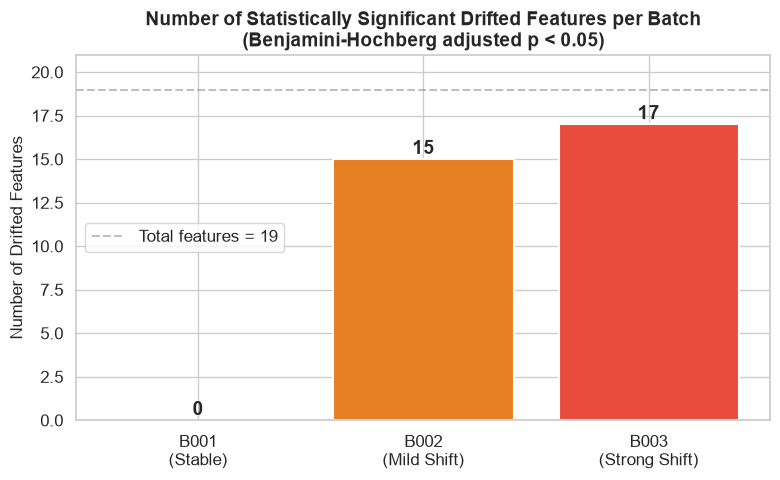

In [14]:
# ── Bar chart: drifted features per batch ──────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

batch_labels = ["B001\n(Stable)", "B002\n(Mild Shift)", "B003\n(Strong Shift)"]
drifted_counts = [d001, d002, d003]
total_features = len(ALL_FEATURES)
colors = ["#2ecc71", "#e67e22", "#e74c3c"]

bars = ax.bar(batch_labels, drifted_counts, color=colors, edgecolor="white", linewidth=1.5)
ax.axhline(y=total_features, color="gray", linestyle="--", alpha=0.5, label=f"Total features = {total_features}")
ax.set_ylabel("Number of Drifted Features")
ax.set_title("Number of Statistically Significant Drifted Features per Batch\n(Benjamini-Hochberg adjusted p < 0.05)", fontweight="bold")
ax.set_ylim(0, total_features + 2)
ax.legend()

for bar, count in zip(bars, drifted_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(count), ha="center", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

### 13.2 Feature-Level Drift Heatmap

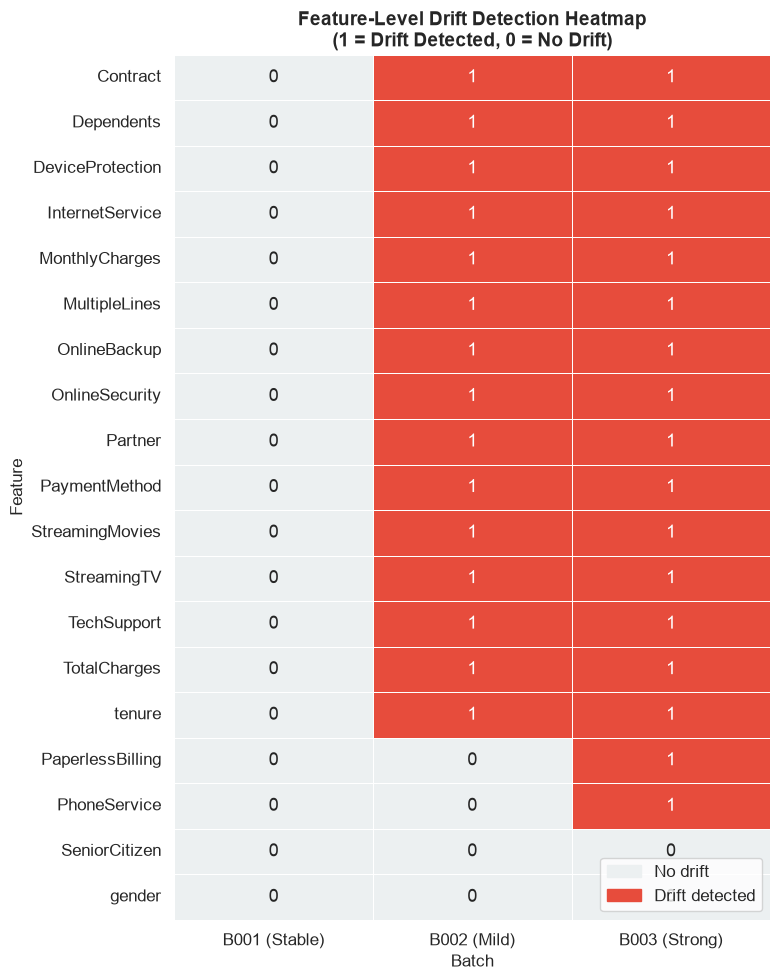

In [15]:
# ── Drift heatmap ──────────────────────────────────────────────────────
pivot_drift = drift_results.pivot_table(
    index="feature", columns="batch_id",
    values="drift_detected", aggfunc="first"
).astype(int)

# Reorder columns
pivot_drift = pivot_drift[["batch_001", "batch_002", "batch_003"]]
pivot_drift.columns = ["B001 (Stable)", "B002 (Mild)", "B003 (Strong)"]

# Sort: drifted features first, then alphabetically
pivot_drift["sort_key"] = pivot_drift.sum(axis=1)
pivot_drift = pivot_drift.sort_values(["sort_key", "feature"], ascending=[False, True]).drop(columns="sort_key")

fig, ax = plt.subplots(figsize=(8, 10))
cmap = sns.color_palette(["#ecf0f1", "#e74c3c"])
sns.heatmap(pivot_drift, annot=True, fmt="d", cmap=cmap, cbar=False,
            linewidths=0.5, linecolor="white", ax=ax)
ax.set_title("Feature-Level Drift Detection Heatmap\n(1 = Drift Detected, 0 = No Drift)", fontweight="bold")
ax.set_ylabel("Feature")
ax.set_xlabel("Batch")

# Add legend
no_drift_patch = mpatches.Patch(color="#ecf0f1", label="No drift")
drift_patch = mpatches.Patch(color="#e74c3c", label="Drift detected")
ax.legend(handles=[no_drift_patch, drift_patch], loc="lower right")

plt.tight_layout()
plt.show()

### 13.3 Distribution of Drift Statistics by Batch

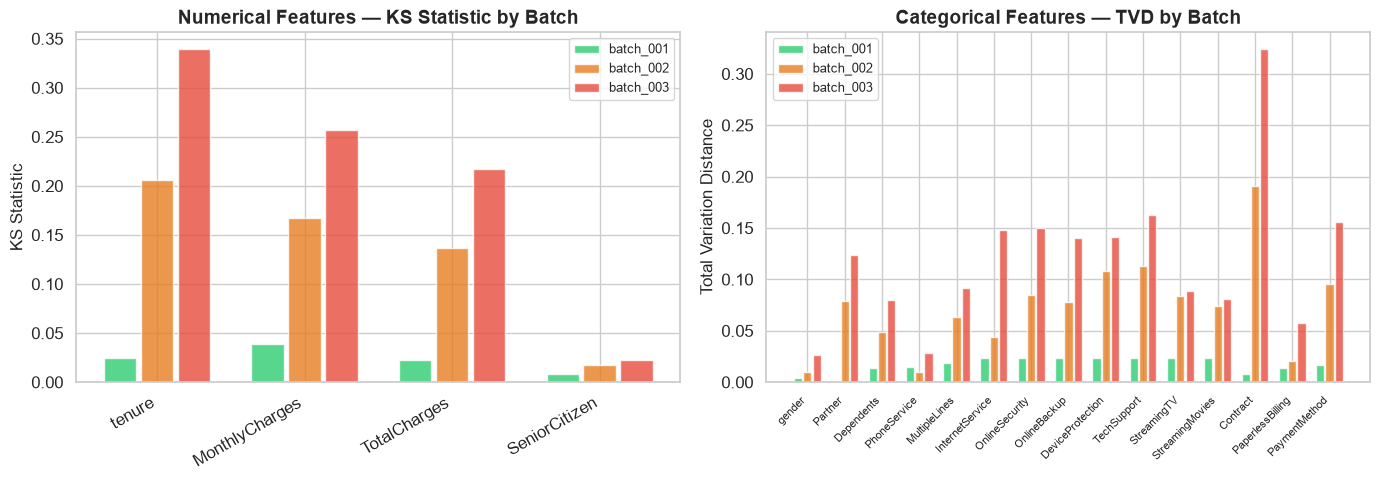

In [16]:
# ── Box plot of magnitude measures ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Numerical: KS statistics
num_data = drift_results[drift_results["feature_type"] == "numerical"]
for i, (bid, color) in enumerate(zip(["batch_001", "batch_002", "batch_003"],
                                      ["#2ecc71", "#e67e22", "#e74c3c"])):
    subset = num_data[num_data["batch_id"] == bid]
    axes[0].bar(
        [f + i*0.25 for f in range(len(NUMERICAL_FEATURES))],
        subset.set_index("feature").loc[NUMERICAL_FEATURES, "magnitude_measure"].values,
        width=0.22, color=color, alpha=0.8, label=bid
    )
axes[0].set_xticks([f + 0.25 for f in range(len(NUMERICAL_FEATURES))])
axes[0].set_xticklabels(NUMERICAL_FEATURES, rotation=30, ha="right")
axes[0].set_ylabel("KS Statistic")
axes[0].set_title("Numerical Features — KS Statistic by Batch", fontweight="bold")
axes[0].legend(fontsize=9)

# Categorical: TVD
cat_data = drift_results[drift_results["feature_type"] == "categorical"]
for i, (bid, color) in enumerate(zip(["batch_001", "batch_002", "batch_003"],
                                      ["#2ecc71", "#e67e22", "#e74c3c"])):
    subset = cat_data[cat_data["batch_id"] == bid]
    axes[1].bar(
        [f + i*0.25 for f in range(len(CATEGORICAL_FEATURES))],
        subset.set_index("feature").loc[CATEGORICAL_FEATURES, "magnitude_measure"].values,
        width=0.22, color=color, alpha=0.8, label=bid
    )
axes[1].set_xticks([f + 0.25 for f in range(len(CATEGORICAL_FEATURES))])
axes[1].set_xticklabels(CATEGORICAL_FEATURES, rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Total Variation Distance")
axes[1].set_title("Categorical Features — TVD by Batch", fontweight="bold")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### 13.4 Selected Feature Comparison: Baseline vs All Batches

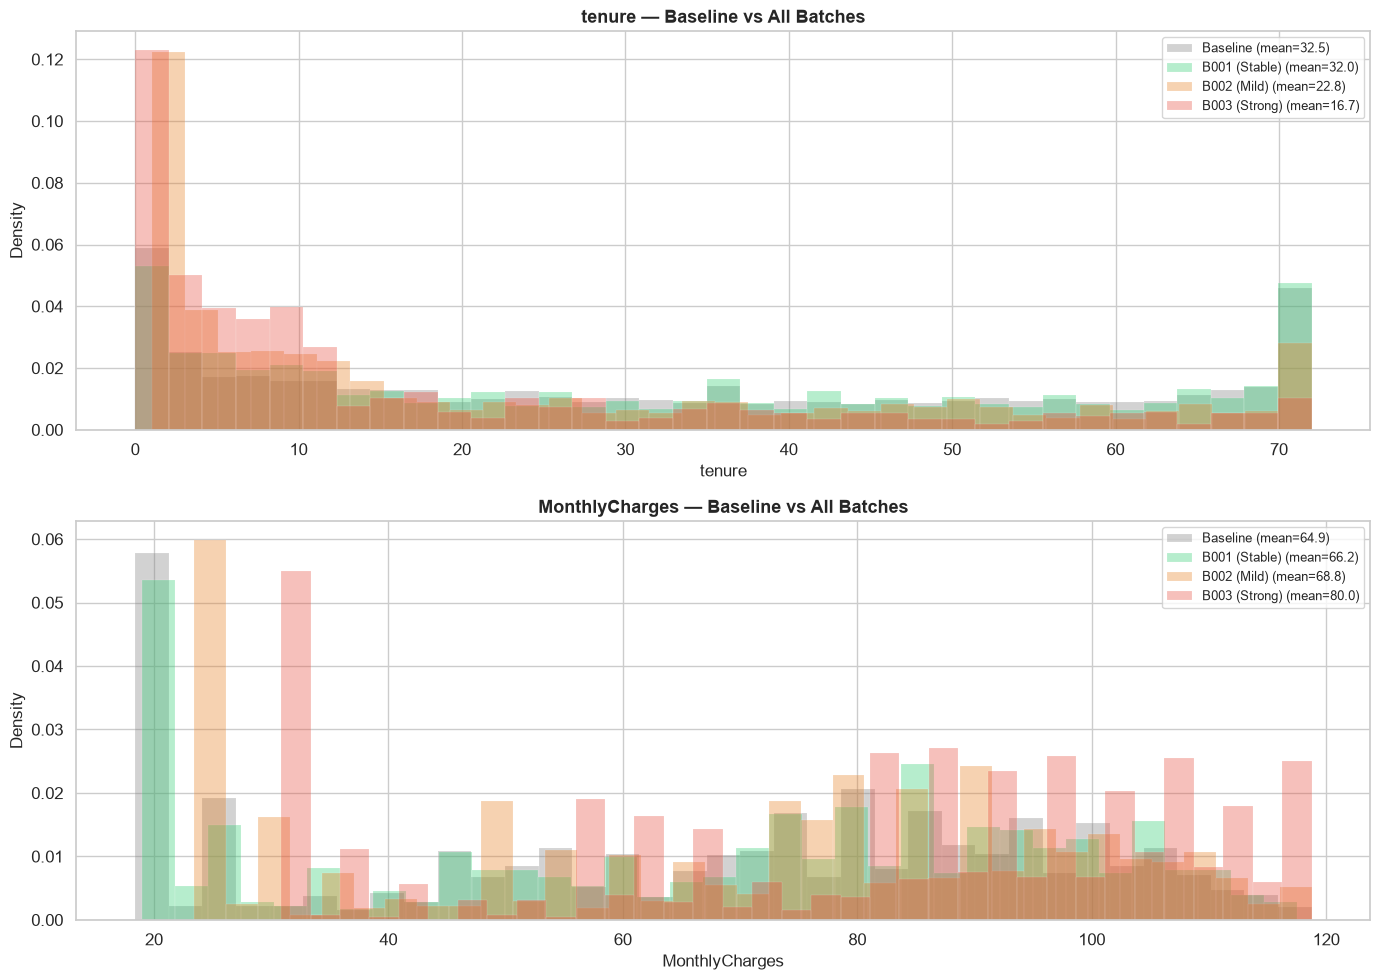

In [17]:
# ── Tenure and MonthlyCharges comparison ───────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

datasets = [
    ("Baseline", baseline_df, "gray"),
    ("B001 (Stable)", batches["batch_001"], "#2ecc71"),
    ("B002 (Mild)", batches["batch_002"], "#e67e22"),
    ("B003 (Strong)", batches["batch_003"], "#e74c3c"),
]

for ax, feat in zip(axes, ["tenure", "MonthlyCharges"]):
    for name, data, color in datasets:
        ax.hist(data[feat].dropna(), bins=35, alpha=0.35, color=color,
                edgecolor="white", linewidth=0.3, label=f"{name} (mean={data[feat].mean():.1f})",
                density=True)
    ax.set_title(f"{feat} — Baseline vs All Batches", fontsize=13, fontweight="bold")
    ax.set_xlabel(feat)
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

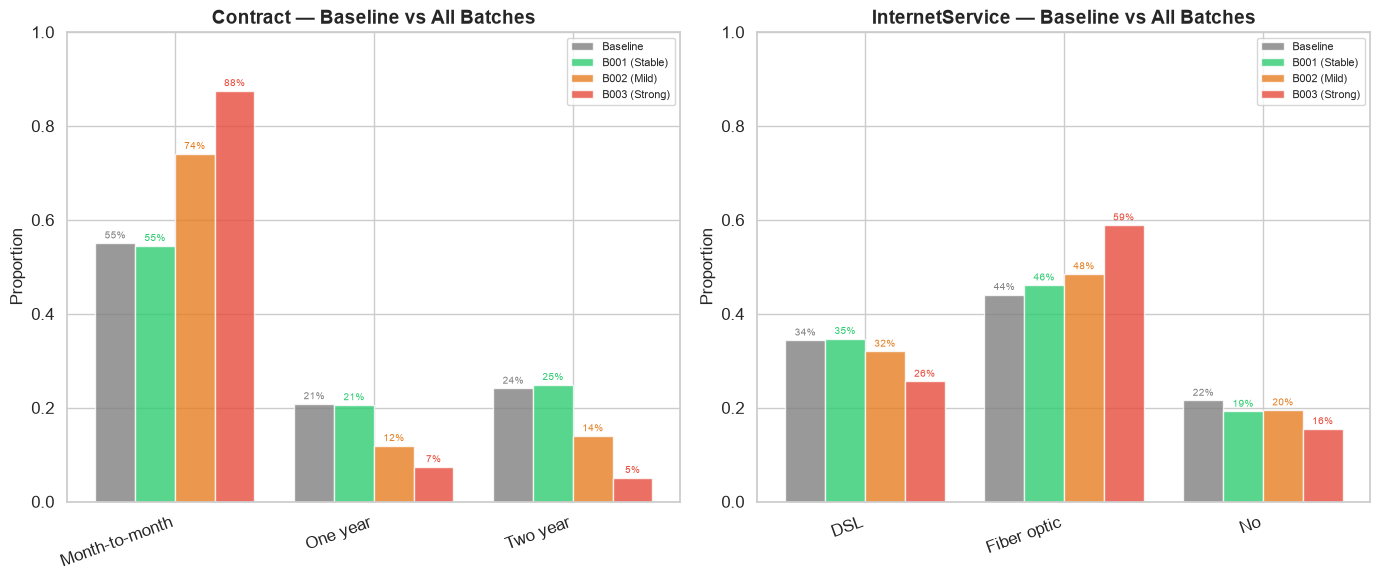

In [18]:
# ── Contract and InternetService comparison ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, feat in zip(axes, ["Contract", "InternetService"]):
    cats = sorted(baseline_df[feat].unique())
    x = np.arange(len(cats))
    width = 0.2

    for i, (name, data, color) in enumerate(datasets):
        props = data[feat].value_counts(normalize=True)
        vals = [props.get(c, 0) for c in cats]
        bars = ax.bar(x + i*width, vals, width, label=name, color=color, alpha=0.8, edgecolor="white")
        for bar, val in zip(bars, vals):
            if val > 0.01:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f"{val:.0%}", ha="center", fontsize=7, color=color)

    ax.set_xticks(x + 1.5 * width)
    ax.set_xticklabels(cats, rotation=20, ha="right")
    ax.set_ylabel("Proportion")
    ax.set_ylim(0, 1.0)
    ax.set_title(f"{feat} — Baseline vs All Batches", fontweight="bold")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 14. Investigate False Positives / False Negatives

Because V7.2 intentionally created known shifts, we can cross-reference the
detection results against the ground truth.

In [19]:
# ── Build validation table ─────────────────────────────────────────────
print("DETECTION vs KNOWN SHIFTS")
print("=" * 90)

for batch_id in ["batch_001", "batch_002", "batch_003"]:
    scenario = batch_scenarios[batch_id]
    shifted = set(batch_shifted[batch_id])
    bdf = drift_results[drift_results["batch_id"] == batch_id]

    print(f"\n--- {batch_id} ({scenario}) ---")
    print(f"  Intentionally shifted: {sorted(shifted) if shifted else 'None'}")
    print()
    print(f"  {'Feature':20s} {'Shifted?':10s} {'Detected?':10s} {'Result':20s} {'adj_p':12s} {'Magnitude':10s}")
    print(f"  {'-'*82}")

    for _, row in bdf.iterrows():
        feat = row["feature"]
        was_shifted = feat in shifted
        was_detected = row["drift_detected"]

        if batch_id == "batch_001":
            # Stable batch: nothing was intentionally shifted
            if was_detected:
                result = "Sampling variability"
            else:
                result = "Expected (stable)"
        else:
            if was_shifted and was_detected:
                result = "✓ Expected detection"
            elif was_shifted and not was_detected:
                result = "⚠ Missed (investigate)"
            elif not was_shifted and was_detected:
                result = "⚠ Secondary effect"
            else:
                result = "✓ Expected (no shift)"

        print(f"  {feat:20s} {'Yes' if was_shifted else 'No':10s} "
              f"{'Yes' if was_detected else 'No':10s} {result:20s} "
              f"{row['adjusted_p_value']:.4e}   {row['magnitude_measure']:.4f}")

DETECTION vs KNOWN SHIFTS

--- batch_001 (stable) ---
  Intentionally shifted: None

  Feature              Shifted?   Detected?  Result               adj_p        Magnitude 
  ----------------------------------------------------------------------------------
  tenure               No         No         Expected (stable)    9.2414e-01   0.0247
  MonthlyCharges       No         No         Expected (stable)    4.0129e-01   0.0389
  TotalCharges         No         No         Expected (stable)    9.4706e-01   0.0225
  SeniorCitizen        No         No         Expected (stable)    1.0000e+00   0.0083
  gender               No         No         Expected (stable)    9.4706e-01   0.0038
  Partner              No         No         Expected (stable)    1.0000e+00   0.0004
  Dependents           No         No         Expected (stable)    5.7603e-01   0.0140
  PhoneService         No         No         Expected (stable)    4.0129e-01   0.0148
  MultipleLines        No         No         Expecte

---
## 15. Save Results

In [20]:
# ── Save drift results CSV ─────────────────────────────────────────────
results_csv_path = DRIFT_DIR / "drift_results_v7.csv"
drift_results.to_csv(results_csv_path, index=False)
print(f"✓ Saved: {results_csv_path}")

# ── Save batch summary CSV ────────────────────────────────────────────
summary_csv_path = DRIFT_DIR / "batch_drift_summary_v7.csv"
batch_summary_df.to_csv(summary_csv_path, index=False)
print(f"✓ Saved: {summary_csv_path}")

# ── Save metadata JSON ───────────────────────────────────────────────
drift_metadata = {
    "version": "V7.3",
    "created_at": datetime.now().isoformat(),
    "description": (
        "Drift detection results comparing V7.2 incoming batches against "
        "the V7.1 baseline distribution. Statistical tests with "
        "Benjamini-Hochberg multiple-testing correction."
    ),
    "alpha": ALPHA,
    "correction_method": CORRECTION_METHOD,
    "correction_description": "Benjamini-Hochberg False Discovery Rate",
    "test_methods": {
        "numerical": "Two-sample Kolmogorov-Smirnov test (scipy.stats.ks_2samp)",
        "categorical": "Chi-square goodness-of-fit test (scipy.stats.chisquare)",
    },
    "magnitude_measures": {
        "numerical": "KS statistic (maximum ECDF separation, 0-1)",
        "categorical": "Total Variation Distance (0.5 * sum|p_base - p_batch|, 0-1)",
    },
    "severity_rules": {
        "LOW": "< 20% of features show statistically significant drift",
        "MEDIUM": "20%-50% of features show drift",
        "HIGH": "> 50% of features show drift",
    },
    "baseline_reference": "artifacts/monitoring/baseline_profile_v7.json",
    "batches_analyzed": ["batch_001", "batch_002", "batch_003"],
    "number_of_features": len(ALL_FEATURES),
    "numerical_features": len(NUMERICAL_FEATURES),
    "categorical_features": len(CATEGORICAL_FEATURES),
}

metadata_path = DRIFT_DIR / "drift_metadata_v7.json"
with open(metadata_path, "w") as f:
    json.dump(drift_metadata, f, indent=2, default=str)
print(f"✓ Saved: {metadata_path}")
print()
print("All V7.3 drift results saved successfully. ✓")

✓ Saved: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/monitoring/drift_results/drift_results_v7.csv
✓ Saved: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/monitoring/drift_results/batch_drift_summary_v7.csv
✓ Saved: /Users/shubhamswaraj/Desktop/PLACEMENT/IntelliPulse/artifacts/monitoring/drift_results/drift_metadata_v7.json

All V7.3 drift results saved successfully. ✓


---
## 16. Reproducibility

The drift engine is deterministic. We verify by running the analysis twice.

In [21]:
# ── Reproducibility check ──────────────────────────────────────────────
print("DRIFT DETECTION REPRODUCIBILITY TEST")
print("=" * 60)

repro_pass = True
for batch_id in ["batch_001", "batch_002", "batch_003"]:
    run1 = detect_drift(
        baseline_df, batches[batch_id],
        NUMERICAL_FEATURES, CATEGORICAL_FEATURES,
        baseline_profile, alpha=ALPHA
    )
    run2 = detect_drift(
        baseline_df, batches[batch_id],
        NUMERICAL_FEATURES, CATEGORICAL_FEATURES,
        baseline_profile, alpha=ALPHA
    )

    stats_match = np.allclose(run1["statistic"].values, run2["statistic"].values)
    pvals_match = np.allclose(run1["p_value"].values, run2["p_value"].values)
    adj_match = np.allclose(run1["adjusted_p_value"].values, run2["adjusted_p_value"].values)
    decisions_match = (run1["drift_detected"].values == run2["drift_detected"].values).all()

    if stats_match and pvals_match and adj_match and decisions_match:
        print(f"  [PASS] {batch_id}: All statistics, p-values, adjusted p-values, and decisions match")
    else:
        print(f"  [FAIL] {batch_id}: Results differ between runs!")
        repro_pass = False

print()
if repro_pass:
    print("Drift detection reproducibility: PASS ✓")
else:
    print("Drift detection reproducibility: FAIL ✗")

DRIFT DETECTION REPRODUCIBILITY TEST
  [PASS] batch_001: All statistics, p-values, adjusted p-values, and decisions match
  [PASS] batch_002: All statistics, p-values, adjusted p-values, and decisions match


  [PASS] batch_003: All statistics, p-values, adjusted p-values, and decisions match

Drift detection reproducibility: PASS ✓


---
## 17. Validation Tests

In [22]:
# ── Automated validation checks ────────────────────────────────────────
print("V7.3 VALIDATION TESTS")
print("=" * 70)

checks_passed = 0
checks_total = 0

# 1. All three batches analyzed
checks_total += 1
batch_ids_in_results = set(drift_results["batch_id"].unique())
if batch_ids_in_results == {"batch_001", "batch_002", "batch_003"}:
    print(f"  [PASS] 1. All three batches analyzed")
    checks_passed += 1
else:
    expected_set = {"batch_001", "batch_002", "batch_003"}
    print(f"  [FAIL] 1. Missing batches: {expected_set - batch_ids_in_results}")

# 2. All 19 features tested per batch
checks_total += 1
features_per_batch = drift_results.groupby("batch_id")["feature"].nunique()
if (features_per_batch == len(ALL_FEATURES)).all():
    print(f"  [PASS] 2. All {len(ALL_FEATURES)} features tested per batch")
    checks_passed += 1
else:
    print(f"  [FAIL] 2. Feature count mismatch: {features_per_batch.to_dict()}")

# 3. Target excluded
checks_total += 1
if TARGET_COL not in drift_results["feature"].values:
    print(f"  [PASS] 3. Target '{TARGET_COL}' excluded from drift testing")
    checks_passed += 1
else:
    print(f"  [FAIL] 3. Target '{TARGET_COL}' found in drift results!")

# 4. Correct test for numerical
checks_total += 1
num_tests = drift_results[drift_results["feature_type"] == "numerical"]["test"].unique()
if len(num_tests) == 1 and "Kolmogorov-Smirnov" in num_tests[0]:
    print(f"  [PASS] 4. Correct test for numerical features: {num_tests[0]}")
    checks_passed += 1
else:
    print(f"  [FAIL] 4. Unexpected test for numerical: {num_tests}")

# 5. Correct test for categorical
checks_total += 1
cat_tests = drift_results[drift_results["feature_type"] == "categorical"]["test"].unique()
if all("Chi-Square" in t for t in cat_tests):
    print(f"  [PASS] 5. Correct test for categorical features: {cat_tests}")
    checks_passed += 1
else:
    print(f"  [FAIL] 5. Unexpected test for categorical: {cat_tests}")

# 6. Adjusted p-values exist
checks_total += 1
if "adjusted_p_value" in drift_results.columns and drift_results["adjusted_p_value"].notna().all():
    print(f"  [PASS] 6. Adjusted p-values exist for all results")
    checks_passed += 1
else:
    print(f"  [FAIL] 6. Missing adjusted p-values")

# 7. No invalid p-values
checks_total += 1
invalid_pvals = ((drift_results["p_value"] < 0) | (drift_results["p_value"] > 1) | drift_results["p_value"].isna()).any()
invalid_adj = ((drift_results["adjusted_p_value"] < 0) | (drift_results["adjusted_p_value"] > 1) | drift_results["adjusted_p_value"].isna()).any()
if not invalid_pvals and not invalid_adj:
    print(f"  [PASS] 7. No invalid p-values (all in [0, 1], no NaN)")
    checks_passed += 1
else:
    print(f"  [FAIL] 7. Invalid p-values detected")

# 8. Drift decisions use adjusted p-values
checks_total += 1
expected_decisions = drift_results["adjusted_p_value"] < ALPHA
if (drift_results["drift_detected"] == expected_decisions).all():
    print(f"  [PASS] 8. Drift decisions correctly use adjusted p-values (alpha={ALPHA})")
    checks_passed += 1
else:
    print(f"  [FAIL] 8. Drift decisions don't match adjusted p-value < {ALPHA}")

# 9. No duplicate feature/batch combinations
checks_total += 1
dupes = drift_results.duplicated(subset=["batch_id", "feature"]).sum()
if dupes == 0:
    print(f"  [PASS] 9. No duplicate feature/batch combinations")
    checks_passed += 1
else:
    print(f"  [FAIL] 9. {dupes} duplicate feature/batch combinations found")

# 10. Output files load correctly
checks_total += 1
try:
    loaded_results = pd.read_csv(results_csv_path)
    loaded_summary = pd.read_csv(summary_csv_path)
    with open(metadata_path) as f:
        loaded_meta = json.load(f)
    assert len(loaded_results) == len(drift_results)
    assert len(loaded_summary) == len(batch_summary_df)
    assert loaded_meta["alpha"] == ALPHA
    print(f"  [PASS] 10. Output files load correctly and match in-memory data")
    checks_passed += 1
except Exception as e:
    print(f"  [FAIL] 10. Error loading output files: {e}")

print()
print("=" * 70)
print(f"  V7.3 validation: {checks_passed}/{checks_total} PASS")
if checks_passed == checks_total:
    print("  STATUS: ALL VALIDATIONS PASSED ✓")
else:
    print(f"  STATUS: {checks_total - checks_passed} CHECK(S) FAILED ✗")
print("=" * 70)

V7.3 VALIDATION TESTS
  [PASS] 1. All three batches analyzed
  [PASS] 2. All 19 features tested per batch
  [PASS] 3. Target 'Churn' excluded from drift testing
  [PASS] 4. Correct test for numerical features: Kolmogorov-Smirnov
  [PASS] 5. Correct test for categorical features: <ArrowStringArray>
['Chi-Square']
Length: 1, dtype: str
  [PASS] 6. Adjusted p-values exist for all results
  [PASS] 7. No invalid p-values (all in [0, 1], no NaN)
  [PASS] 8. Drift decisions correctly use adjusted p-values (alpha=0.05)
  [PASS] 9. No duplicate feature/batch combinations
  [PASS] 10. Output files load correctly and match in-memory data

  V7.3 validation: 10/10 PASS
  STATUS: ALL VALIDATIONS PASSED ✓


---
## 18. Statistical Interpretation

### Null Hypothesis

**Numerical (KS test):**
> H₀: The baseline and incoming samples come from the same continuous distribution.

**Categorical (Chi-square):**
> H₀: The incoming category proportions follow the baseline distribution.

### P-Value

The p-value is the probability of observing a test statistic at least as extreme as
the one computed, **assuming the null hypothesis is true**.

**What it is NOT:**
- It is NOT the probability that drift exists.
- It is NOT the probability that the null hypothesis is true.
- A small p-value provides *evidence against* H₀, but does not *prove* drift.

### KS Statistic

The KS statistic (D) is the maximum vertical distance between the empirical CDFs of
the two samples. It ranges from 0 (identical distributions) to 1 (completely
separated distributions). It is sensitive to any difference in the distributions —
location, scale, or shape.

### Chi-Square Statistic

The chi-square statistic measures the discrepancy between observed incoming category
counts and the counts expected under the baseline distribution:

χ² = Σ (observed_i − expected_i)² / expected_i

Larger values indicate greater deviation from the baseline.

### Multiple Testing Problem

When testing 19 features at α = 0.05, we expect approximately 19 × 0.05 ≈ 0.95
false positives by chance alone — even if no feature has truly drifted. This inflates
the risk of incorrectly flagging features as drifted.

### Benjamini-Hochberg Correction

The Benjamini-Hochberg (BH) procedure controls the **False Discovery Rate (FDR)** —
the expected proportion of false discoveries among all rejected hypotheses. It adjusts
the p-values upward, making it harder to reject H₀ and thereby reducing false positives.

We use the **adjusted p-values** (not raw p-values) for drift decisions.

### Practical Significance

Statistical significance depends on both the effect size and the sample size. With
large samples, even tiny, practically irrelevant differences can be statistically
significant.

We therefore also report **magnitude measures**:
- **KS statistic** for numerical features (0 = identical, 1 = fully separated)
- **Total Variation Distance** for categorical features (0 = identical, 1 = no overlap)

These help distinguish between:
- **Statistical evidence:** "The distributions differ" (p-value)
- **Magnitude of change:** "How much they differ" (KS/TVD)

---
## 19. Important Limitations

1. **Simulated data:** V7.2 batches are simulated from the training data, not real
   production traffic. Real-world drift patterns may be more subtle or complex.

2. **Drift ≠ model degradation:** Statistical drift in input features does not
   automatically imply that model performance has degraded. A feature may shift
   without affecting prediction quality.

3. **Drift ≠ retraining trigger:** Detecting drift does not automatically mean the
   model must be retrained. Business context and model performance metrics should
   inform retraining decisions.

4. **Correlated features:** Features in this dataset are correlated (e.g., tenure,
   TotalCharges, Contract). Drift in one feature may cause secondary detection in
   correlated features. Individual feature-level interpretation should account for
   this.

5. **Threshold choice:** The α = 0.05 threshold and the severity classification
   boundaries (20%, 50%) are monitoring choices, not universal truths. Different
   contexts may warrant different thresholds.

6. **Input distribution only:** V7.3 monitors input (feature) distributions only.
   Model performance monitoring (accuracy, precision, recall on new data) is
   addressed in later versions.

7. **Sample size sensitivity:** The KS and chi-square tests are sensitive to sample
   size. With very large samples, even small differences become statistically
   significant. The magnitude measures (KS statistic, TVD) help contextualize this.

---
## 20. Final V7.3 Report

In [23]:
# ── Final report ───────────────────────────────────────────────────────
print("=" * 80)
print("  IntelliPulse V7.3 — Drift Detection Engine Report")
print("=" * 80)
print()

# ── Overall Results ───────────────────────────────────────────────────
print("OVERALL RESULTS")
print("-" * 70)
for _, row in batch_summary_df.iterrows():
    print(f"\n  {row['batch_id']} ({row['scenario']}):")
    print(f"    Total features   : {row['total_features']}")
    print(f"    Drifted features : {row['drifted_features']} ({row['drift_percentage']}%)")
    print(f"    Severity         : {row['severity']}")
    print(f"    Numerical drifted: {row['numerical_drifted']}")
    print(f"    Categorical drift: {row['categorical_drifted']}")
    if row['drifted_features'] > 0:
        print(f"    Avg magnitude    : {row['avg_magnitude']:.4f}")
    # Most affected features
    bdf = drift_results[(drift_results["batch_id"] == row["batch_id"]) & drift_results["drift_detected"]]
    if len(bdf) > 0:
        top = bdf.nlargest(3, "magnitude_measure")
        top_str = ", ".join(f"{r['feature']}({r['magnitude_measure']:.3f})" for _, r in top.iterrows())
        print(f"    Most affected    : {top_str}")

# ── Key Findings ──────────────────────────────────────────────────────
print()
print("\nKEY FINDINGS")
print("-" * 70)

# Find features with strongest drift evidence across all batches
strongest = drift_results[drift_results["drift_detected"]].copy()
if len(strongest) > 0:
    feat_summary = strongest.groupby("feature").agg(
        times_detected=("drift_detected", "sum"),
        max_magnitude=("magnitude_measure", "max"),
    ).sort_values(["times_detected", "max_magnitude"], ascending=[False, False])

    print("  Features with strongest drift evidence (across all batches):")
    for feat, row in feat_summary.head(5).iterrows():
        print(f"    {feat:20s}: detected {int(row['times_detected'])}x, max magnitude={row['max_magnitude']:.4f}")
else:
    print("  No features showed statistically significant drift in any batch.")

# ── Experiment Validation ─────────────────────────────────────────────
print()
print("\nEXPERIMENT VALIDATION")
print("-" * 70)

if d001 <= d002 <= d003:
    print("  Stable → Mild → Strong produced an increasingly detectable pattern. ✓")
    print(f"  Drifted features: {d001} → {d002} → {d003}")
else:
    print("  The expected Stable ≤ Mild ≤ Strong pattern was NOT strictly observed.")
    print(f"  Drifted features: {d001} → {d002} → {d003}")
    print("  Investigation notes are documented in Section 11.")

# ── Engineering Status ────────────────────────────────────────────────
print()
print("\nENGINEERING STATUS")
print("-" * 70)
print("  V7.1 baseline           : COMPLETE")
print("  V7.2 batch generation   : COMPLETE")
print("  V7.3 drift detection    : COMPLETE")

# ── Explicit Scope ────────────────────────────────────────────────────
print()
print("\nSCOPE")
print("-" * 70)
print('  "V7.3 detects input-data distribution drift.')
print('   It does not measure model performance degradation."')

# ── File Locations ────────────────────────────────────────────────────
print()
print("\nSAVED ARTIFACTS")
print("-" * 70)
print(f"  • {DRIFT_DIR / 'drift_results_v7.csv'}")
print(f"  • {DRIFT_DIR / 'batch_drift_summary_v7.csv'}")
print(f"  • {DRIFT_DIR / 'drift_metadata_v7.json'}")

print()
print("=" * 80)

  IntelliPulse V7.3 — Drift Detection Engine Report

OVERALL RESULTS
----------------------------------------------------------------------

  batch_001 (stable):
    Total features   : 19
    Drifted features : 0 (0.0%)
    Severity         : LOW
    Numerical drifted: 0
    Categorical drift: 0

  batch_002 (mild_shift):
    Total features   : 19
    Drifted features : 15 (78.9%)
    Severity         : HIGH
    Numerical drifted: 3
    Categorical drift: 12
    Avg magnitude    : 0.1049
    Most affected    : tenure(0.206), Contract(0.190), MonthlyCharges(0.167)

  batch_003 (strong_shift):
    Total features   : 19
    Drifted features : 17 (89.5%)
    Severity         : HIGH
    Numerical drifted: 3
    Categorical drift: 14
    Avg magnitude    : 0.1521
    Most affected    : tenure(0.340), Contract(0.324), MonthlyCharges(0.257)


KEY FINDINGS
----------------------------------------------------------------------
  Features with strongest drift evidence (across all batches):
    t